# Example Explanation Visualization

This notebook normalises the raw contrastive-parity attribution heatmaps and renders a
three-panel figure for a single MuST-SHE sample: input filterbank spectrogram, normalised
attribution heatmap, and a binary mask of the top-2% most salient time–frequency bins,
with word boundaries from forced alignment overlaid on every panel.

## Inputs

| Name | Description | How to obtain |
|---|---|---|
| `summary_dataframe.tsv` | One row per gender term instance, with model predictions, ILM probabilities, flip thresholds, and training data term frequencies. | Output of `prepare_df_for_analysis_clean.ipynb` (`output_path`). |
| `fbank/` directory | Per-sample filterbank feature arrays (`.npy` files), named `<id>.npy`. | Generated in step 0 of `CONTRASTIVE_SPES.md` (Speechformer preprocessing of MuST-SHE). |
| `gender_explanations.h5` | Raw (unnormalised) feature attribution heatmaps from the contrastive-parity occlusion method. | Generated in step 3 of `CONTRASTIVE_SPES.md`. |
| Gentle alignment JSONs | Per-utterance word-level forced-alignment files (Gentle format). | Run the [Gentle forced aligner](https://github.com/lowerquality/gentle) on the MuST-SHE audio. |

## Output

- `normalized_explanations.h5` — normalised heatmaps written to `NORMALIZED_EXPLANATIONS_H5` (reusable by downstream analysis notebooks)
- A three-panel matplotlib figure:
  - **(a)** Input filterbank spectrogram
  - **(b)** Normalised attribution heatmap
  - **(c)** Binary mask of the top 2% most salient features

Word boundaries from the Gentle alignment appear as vertical red dashed lines across all panels.

## Imports

In [19]:
import csv
import os
import json

import h5py
import numpy as np
import pandas as pd
import torch
from torch import Tensor
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from examples.speech_to_text.occlusion_explanation.normalizers import get_normalizer
from examples.speech_to_text.occlusion_explanation.utils.readers import read_feature_attribution_maps_from_h5

## Configuration

Set all paths and parameters in this cell before running the notebook.

In [20]:
LANG = "it"            # one of: es, fr, it
MODEL = "transformer"  # one of: transformer, conformer

# summary_dataframe.tsv – output of prepare_df_for_analysis_clean.ipynb (output_path)
SUMMARY_TSV = f"/path/to/results/{MODEL}/en-{LANG}/summary_dataframe.tsv"

# fbank/ – filterbank feature files from step 0 of CONTRASTIVE_SPES.md
FBANK_FOLDER = f"/path/to/preprocessed/{LANG}/fbank/"

# gender_explanations.h5 – raw attribution heatmaps from step 3 of CONTRASTIVE_SPES.md
GENDER_EXPLANATIONS_H5 = f"/path/to/results/{MODEL}/en-{LANG}/contrastive_parity/gender_explanations.h5"

# normalized_explanations.h5 – output of Section 2; also used by downstream analysis notebooks
NORMALIZED_EXPLANATIONS_H5 = f"/path/to/results/{MODEL}/en-{LANG}/contrastive_parity/normalized_explanations.h5"

# Directory of Gentle forced-alignment JSON files, one per utterance
JSON_FOLDER = "/path/to/gentle_alignments/json"

# Row index in SUMMARY_TSV of the sample to visualize
SAMPLE_KEY = 709

## 1. Load Data

Read the evaluation metadata table and the raw attribution heatmaps from disk.

In [ ]:
df = pd.read_csv(SUMMARY_TSV, sep='\t', escapechar='\\', quoting=csv.QUOTE_NONE)
explanations = read_feature_attribution_maps_from_h5(GENDER_EXPLANATIONS_H5)

## 2. Normalize and Save Explanations

Apply per-sample mean–std then min–max normalisation to the raw attribution heatmaps,
using the gender term token position to anchor the normalisation. The normalised heatmaps
are saved to `NORMALIZED_EXPLANATIONS_H5` for reuse by downstream analysis notebooks;
the `explanations` dict is also updated in memory for immediate use in Section 5.

In [ ]:
mean_normalizer = get_normalizer('gender_single_mean_std')()
min_max_normalizer = get_normalizer('gender_single_min_max')()

with h5py.File(NORMALIZED_EXPLANATIONS_H5, 'w') as f:
    for idx in df.index:
        # Start token index of the gender term, used to anchor the normalisation of the previous output token explanations
        gt_index = int(df.loc[idx, 'gender_terms_indices'].split('-')[0])

        explanations[idx]["fbank_heatmap"], explanations[idx]["tgt_embed_heatmap"] = mean_normalizer(
            explanations[idx]["fbank_heatmap"], explanations[idx]["tgt_embed_heatmap"], gt_index)

        explanations[idx]["fbank_heatmap"], explanations[idx]["tgt_embed_heatmap"] = min_max_normalizer(
            explanations[idx]["fbank_heatmap"], explanations[idx]["tgt_embed_heatmap"], gt_index)

        group = f.create_group(str(idx))
        for key, value in explanations[idx].items():
            group.create_dataset(key, data=value.cpu() if isinstance(value, Tensor) else value)

## 3. Frequency Axis Utilities

Convert mel-bin indices to Hz so that the y-axis tick labels show human-readable frequencies.

In [25]:
def mel_to_hertz(mel):
    """Convert a mel-scale value to Hz."""
    return 700 * (10 ** (mel / 2595) - 1)


def mel_bin_frequencies(num_mel_bins, min_freq_hz, max_freq_hz):
    """Return (low_hz, high_hz) pairs for each of the num_mel_bins mel-filterbank bins."""
    min_mel = 2595 * np.log10(1 + min_freq_hz / 700)
    max_mel = 2595 * np.log10(1 + max_freq_hz / 700)
    mel_points = np.linspace(min_mel, max_mel, num_mel_bins + 1)
    freq_points = mel_to_hertz(mel_points)
    return [(freq_points[i], freq_points[i + 1]) for i in range(num_mel_bins)]


# Mel-filterbank parameters matching the model's feature extraction
NUM_MEL_BINS = 80
MIN_FREQ_HZ = 0
MAX_FREQ_HZ = 8000
_frequency_ranges = mel_bin_frequencies(NUM_MEL_BINS, MIN_FREQ_HZ, MAX_FREQ_HZ)


def bin_to_frequency(bin_index, pos, frequency_ranges=_frequency_ranges):
    """Return the centre frequency (kHz, integer) for a mel-bin index.

    The pos argument is required by matplotlib's FuncFormatter but is unused here.
    """
    centre_hz = (frequency_ranges[bin_index][0] + frequency_ranges[bin_index][1]) / 2
    return int(round(centre_hz / 1000, 0))

## 4. Plotting Functions

`make_explanation_binary` thresholds an attribution map to keep only the most salient bins.
`plot_all_with_align` renders the three-panel figure with word-boundary overlays.

In [26]:
def make_explanation_binary(explanation, keep_percent=1):
    """Return a binary copy of explanation retaining the top keep_percent% values."""
    binary_exp = explanation.clone()
    threshold = torch.quantile(binary_exp.flatten(), 1 - keep_percent / 100)
    binary_exp[binary_exp < threshold] = 0
    binary_exp[binary_exp >= threshold] = 1
    return binary_exp


def plot_all_with_align(
        mustshe_id: str,
        fbank: torch.Tensor,
        fbank_explanation: torch.Tensor,
        binary_explanation: torch.Tensor,
):
    """Plot spectrogram, attribution heatmap, and binary mask with word-alignment overlays.

    Args:
        mustshe_id: Base utterance ID used to locate the Gentle alignment JSON (e.g. "it-0742").
        fbank: Filterbank feature tensor of shape (T, F).
        fbank_explanation: Normalised attribution heatmap tensor of shape (1, T, F).
        binary_explanation: Binarised attribution tensor of shape (1, T, F).
    """
    json_path = os.path.join(JSON_FOLDER, mustshe_id)
    with open(json_path, 'r') as f:
        # Keep only words for which Gentle produced a successful alignment
        words = [d for d in json.load(f)['words'] if d['case'] == 'success']

    # Gentle timestamps are in seconds; feature frame rate is ~100 fps
    word_positions = [(word['start'] + word['end']) / 2 * 100 for word in words]
    word_labels = [word['word'] for word in words]

    fig, axs = plt.subplots(3, 1, figsize=(6, 6), constrained_layout=False)

    axs[0].imshow(fbank.T, cmap='Greys', interpolation='nearest',
                  vmin=fbank.min().item(), vmax=fbank.max().item(), aspect='equal')
    axs[0].invert_yaxis()
    axs[0].set_title("(a) Input Spectrogram")

    axs[1].imshow(fbank_explanation[0].numpy().T, cmap='viridis',
                  interpolation='nearest', vmin=0, vmax=1, aspect='equal')
    axs[1].invert_yaxis()
    axs[1].set_title("(b) Feature Attribution Heatmap")

    axs[2].imshow(binary_explanation[0].numpy().T, cmap='gray',
                  interpolation='nearest', vmin=0, vmax=1, aspect='equal')
    axs[2].invert_yaxis()
    axs[2].set_title("(c) Top 2% Most Salient Features")

    fig.supxlabel('Time')
    fig.supylabel('Frequency (kHz)')

    for ax in axs:
        # Tick at low (0 Hz), mid (~3.9 kHz), and high (~8 kHz) mel bins
        ax.set_yticks([0, 39, 79])
        ax.yaxis.set_major_formatter(FuncFormatter(bin_to_frequency))

        for word in words:
            ax.axvline(x=word['start'] * 100, color='red', linestyle='--', linewidth=0.8)
            ax.axvline(x=word['end'] * 100, color='red', linestyle='--', linewidth=0.8)

    for ax in axs[:-1]:
        ax.get_xaxis().set_visible(False)

    axs[-1].set_xticks(word_positions)
    axs[-1].set_xticklabels(word_labels, fontsize=9)
    plt.setp(axs[-1].get_xticklabels(), rotation=45, ha="right", fontsize=11)

    plt.tight_layout()
    plt.show()

## 5. Generate Example Plot

Load the filterbank features for the selected sample and render the three-panel figure.

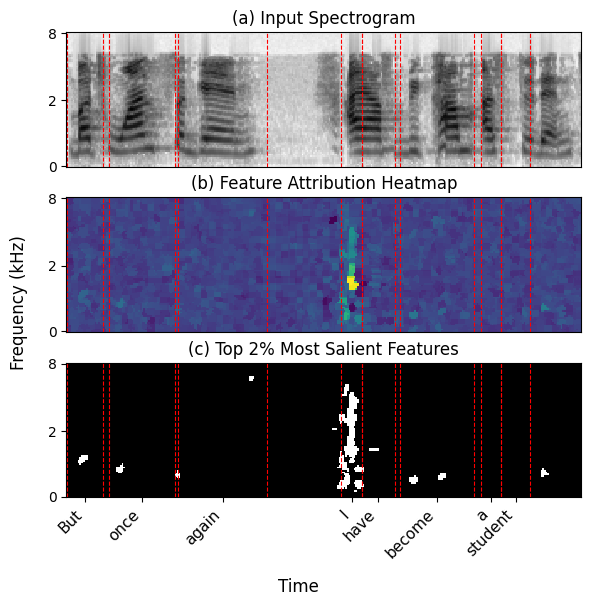

In [27]:
fbank = np.load(os.path.join(FBANK_FOLDER, df.loc[SAMPLE_KEY]["id"] + ".npy"))

# Sample IDs include a frame-range suffix (e.g. "it-0742_0"); strip it to get the base
# utterance ID used as the Gentle alignment JSON filename
base_id = df.loc[SAMPLE_KEY]["id"].split('_')[0]

plot_all_with_align(
    base_id,
    torch.tensor(fbank),
    explanations[SAMPLE_KEY]["fbank_heatmap"],
    make_explanation_binary(explanations[SAMPLE_KEY]["fbank_heatmap"], 2),
)